<a href="https://colab.research.google.com/github/Mizuko821/master_thesis/blob/main/%E5%AE%9F%E9%A8%932_%E3%82%B7%E3%83%B3%E3%82%B0%E3%83%AB%E3%82%BF%E3%82%B9%E3%82%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##環境
Google Colabratory  
ランタイム:GPU（V100）を使用

In [ ]:
!pip install transformers torch
!pip install accelerate -U
!pip install fugashi ipadic

In [ ]:
import os
import json
import re
import pandas as pd
from transformers import AutoTokenizer, BertTokenizer, BertPreTrainedModel, BertModel, AdamW, get_linear_schedule_with_warmup, TrainingArguments
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, RandomSampler, SequentialSampler
from torch.optim import AdamW
import matplotlib.pyplot as plt
from torch import nn
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.manifold import TSNE
import numpy as np
from typing import Tuple
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.metrics import f1_score, classification_report

In [ ]:
# デバイスの設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def set_seed(seed_value):
    """Set seed for reproducibility.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

set_seed(42)

In [ ]:
#Twitterデータセットへのファイルのパスを設定する
tweet_path = "パスを入力する"

In [ ]:
# CSVファイルを読み込む
df = pd.read_csv(tweet_path)
df.head()

,target,sentence,polarity
0,インボイス制度,フリーランスや、フリーランスへの親近感が強い方が多めのタイムライン構成なので、インボイス制度...,positive
1,インボイス制度,個人的な意見だが徴税制度がすべて悪とは思ってない。インボイス制度はわけのわからん軽減率より分...,positive
2,インボイス制度,こんな状況にもかかわらずインボイス制度賛成というのは理解が難しいです。大企業ではなく、個人事...,negative
3,インボイス制度,インボイス制度はそもそも反対なのだが、まず前提として、あらゆる手続きの負荷は簡便であることを...,negative
4,インボイス制度,インボイス制度何が何でも反対！の人が多いけど消費税払ってるちっさい会社の立場としてはなんでそ...,positive


In [ ]:
# 改行コードを削除
df['sentence'] = df['sentence'].apply(lambda x: re.sub(r'\r?\n', '', x))
df['sentence']

0      フリーランスや、フリーランスへの親近感が強い方が多めのタイムライン構成なので、インボイス制度...
1      個人的な意見だが徴税制度がすべて悪とは思ってない。インボイス制度はわけのわからん軽減率より分...
2      こんな状況にもかかわらずインボイス制度賛成というのは理解が難しいです。大企業ではなく、個人事...
3      インボイス制度はそもそも反対なのだが、まず前提として、あらゆる手続きの負荷は簡便であることを...
4      インボイス制度何が何でも反対！の人が多いけど消費税払ってるちっさい会社の立場としてはなんでそ...
                             ...                        
140    選択的夫婦別姓のメリットは・姓を理由として結婚しなかった人たちが結婚に踏み切れる・親子での姓...
141    そもそも「選択的夫婦別姓が“ないから”結婚できない夫婦」はいても、「選択的夫婦別姓“あるから...
142    選択的夫婦別姓ってノーリスクでリターンしかないと思ってたけど、別姓にしなかった場合に「同姓に...
143    選択的夫婦別姓の問題点について考えてみたが、戸籍とかその辺の法律改正含むし、大混乱になる可能...
144    「選択的夫婦別姓」を私が素直に賛成できないのは、それで生まれた子ども自身が「選択するわけでは...
Name: sentence, Length: 145, dtype: object

In [ ]:
# 極性ラベルを数字にマッピング
label_mapping = {"positive": 0, "neutral": 1, "negative": 2}
df["pol_labels"] = df["polarity"].map(label_mapping)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, target, sentence, pol_labels):
        self.target = target.values
        self.sentence = sentence.values
        self.pol_labels = pol_labels.values

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        return self.target[idx], self.sentence[idx], torch.tensor(self.pol_labels[idx], dtype=torch.long)

In [ ]:
# データセットを作成
tweetset = TextDataset(pd.Series(df["target"]), pd.Series(df["sentence"]), pd.Series(df["pol_labels"]))

In [ ]:
# DataLoaderのパラメータ設定
batch_size = 16
num_pol_labels = 3


# テスト用データローダー
tweet_dataloader = DataLoader(
    tweetset,
    batch_size=batch_size
)

### モデル実装（極性分類+カテゴリー分類）

In [ ]:
class SingleTaskModel(BertPreTrainedModel):

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config

        self.bert = BertModel(config)

        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None \
                else config.hidden_dropout_prob
        )

        # 極性分類用のネットワーク
        self.pol_dropout = nn.Dropout(classifier_dropout)
        self.pol_layer1 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation1 = nn.ReLU()
        self.pol_layer2 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation2 = nn.ReLU()
        self.pol_classifier = nn.Linear(config.hidden_size, config.num_labels)

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, pol_labels=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)
        pooled_output = outputs[1]
        pooled_output = self.pol_dropout(pooled_output)

        # 感情分類のロジット
        pol_out = self.pol_activation1(self.pol_layer1(pooled_output))
        pol_out = self.pol_activation2(self.pol_layer2(pol_out))
        pol_logits = self.pol_classifier(pol_out)

        return {
            "pol_logits": pol_logits,
            "hidden_states": outputs.hidden_states,
            "attentions": outputs.attentions,
            "pooler_output":outputs.pooler_output
        }

In [ ]:
# 1. モデルアーキテクチャの初期化
#tokenizerとmodelのインスタンス化
modelName = 'cl-tohoku/bert-base-japanese-whole-word-masking'
tokenizer =  AutoTokenizer.from_pretrained(modelName)
model = SingleTaskModel.from_pretrained(modelName, num_labels=num_pol_labels).to(device)

tokenizer_config.json:   0%|          | 0.00/110 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/258k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of SingleTaskModel were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking and are newly initialized: ['pol_layer2.weight', 'pol_classifier.weight', 'pol_classifier.bias', 'pol_layer1.weight', 'pol_layer1.bias', 'pol_layer2.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#保存された状態辞書のロード
model_path = "実験1で学習したモデルへのパスを入力する"

model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [ ]:
# モデルを評価モードに設定
model.eval()

total_loss, pol_total_correct, total_samples = 0, 0, len(tweetset)
pol_predictions, pol_labels_list = [], []

pooler_output = []
pol_labels_list = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

loss_fct = nn.CrossEntropyLoss()

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(tweet_dataloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()
        pooler_output.append(pred["pooler_output"])

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })


avg_loss = total_loss / len(tweet_dataloader)
pol_accuracy = pol_total_correct / total_samples

# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')

# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 2.3589
Test Pol Accuracy: 0.4000, F1: 0.3998
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40        51
           1       0.36      0.46      0.40        48
           2       0.38      0.41      0.40        46

    accuracy                           0.40       145
   macro avg       0.41      0.40      0.40       145
weighted avg       0.42      0.40      0.40       145



### Counfusion Matrix

In [ ]:
# Confusion Matrixの計算
polarity_cm = confusion_matrix(pol_labels_list, pol_predictions)

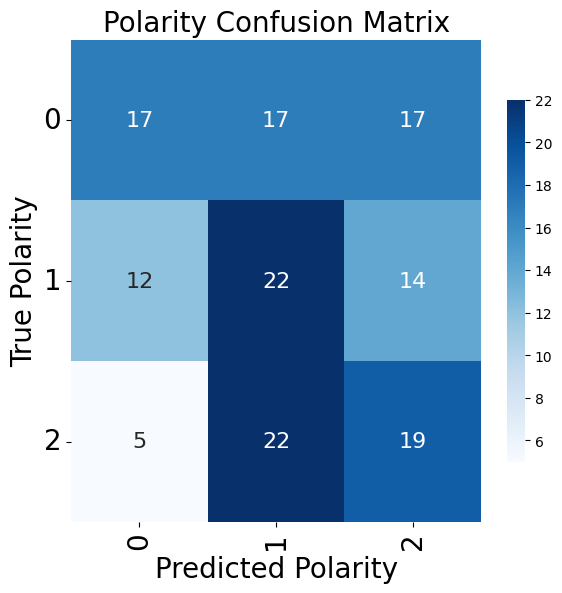

In [ ]:
# Confusion Matrixの計算後...
plt.figure(figsize=(6, 6))  # サイズ調整

sns.heatmap(polarity_cm, annot=True, fmt="", cmap='Blues', cbar_kws={"shrink": 0.75}, annot_kws={"size": 16})
plt.xlabel('Predicted Polarity', fontsize=20)
plt.ylabel('True Polarity', fontsize=20)
plt.title('Polarity Confusion Matrix', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

### 不正解の事例

In [ ]:
len(incorrect_polarity_samples)

87

In [ ]:
incorrect_polarity_samples

[{'batch_index': 0,
  'sample_index': 0,
  'target': 'インボイス制度',
  'sentence': 'フリーランスや、フリーランスへの親近感が強い方が多めのタイムライン構成なので、インボイス制度に反対する意見をよく見るんだけど、一般企業の経理職を長くやってきた経験からするとインボイス制度わりと賛成なんですよね。',
  'predicted_label': 2,
  'correct_label': 0},
 {'batch_index': 0,
  'sample_index': 2,
  'target': 'インボイス制度',
  'sentence': 'こんな状況にもかかわらずインボイス制度賛成というのは理解が難しいです。大企業ではなく、個人事業主達の税負担が増え、経費精算が煩わしくなる上に、こんな金の使い方をする現与党に米櫃に手を突っ込ませるのは意味がわからない。「私は税理士雇えるから大丈夫」というレベルの問題じゃないのに。',
  'predicted_label': 1,
  'correct_label': 2},
 {'batch_index': 0,
  'sample_index': 3,
  'target': 'インボイス制度',
  'sentence': 'インボイス制度はそもそも反対なのだが、まず前提として、あらゆる手続きの負荷は簡便であることを目指すべき、なぜなら多くの人類は事務能力がそれほどないから、事務能力は結構特殊能力、人間のリソースは限られている、仕組みで限られたリソースの可動域を広げるべき、と思っているのが少数なのか？',
  'predicted_label': 1,
  'correct_label': 2},
 {'batch_index': 0,
  'sample_index': 4,
  'target': 'インボイス制度',
  'sentence': 'インボイス制度何が何でも反対！の人が多いけど消費税払ってるちっさい会社の立場としてはなんでそれ利益になんねん、と思ってるから賛成です。',
  'predicted_label': 1,
  'correct_label': 0},
 {'batch_index': 0,
  'sample_ind